In [1]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from utils.evaluation import evaluate_pipeline
from utils import column_type_split

In [2]:
df = pd.read_csv("../data/train_clear_hepatitis_undiff.csv")

In [3]:
target = "Liver_Disease_Type"
X = df.drop(columns=[target])
y = df[target]

In [4]:
columns = column_type_split(X)

In [5]:
pipe_lr = Pipeline(
    [
        (
            "preprocess",
            ColumnTransformer(
                [
                    ("ohe", OneHotEncoder(drop="first"), columns.categorical),
                    ("scaler", StandardScaler(), columns.numeric),
                ],
                remainder="passthrough",
            ),
        ),
        ("logistic", LogisticRegression(max_iter=200)),
    ]
)

Модель LogisticRegression
F1-macro: 0.843 ± 0.004
F1-weighted: 0.854 ± 0.004


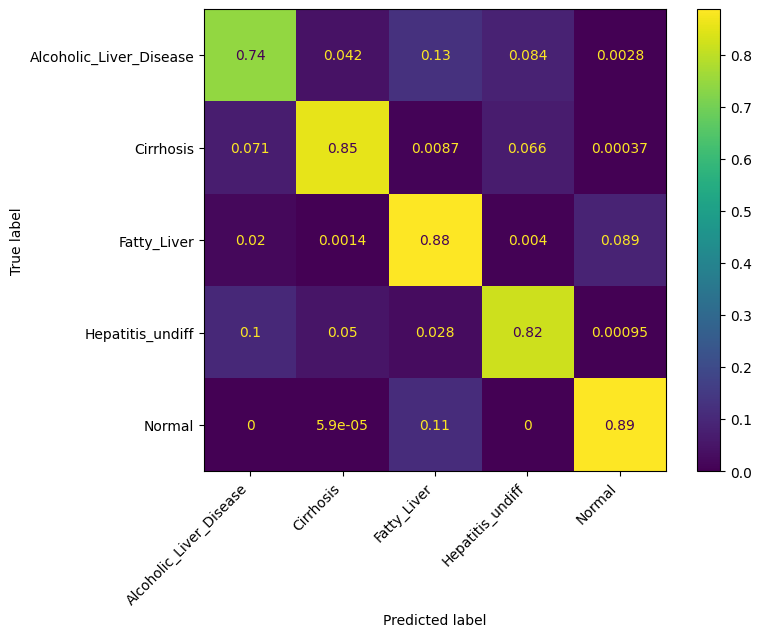

In [6]:
evaluate_pipeline(pipe_lr, X, y)

In [7]:
pipe_xgb = Pipeline(
        [
            (
                "preprocess",
                ColumnTransformer(
                    [
                        (
                            "ordinal",
                            OrdinalEncoder(
                                handle_unknown="use_encoded_value",
                                unknown_value=-1,
                                dtype=np.int64,
                            ),
                            columns.categorical,
                        )
                    ],
                    remainder="passthrough",
                ),
            ),
            ("xgb", XGBClassifier()),
        ]
    )

Модель XGBClassifier
F1-macro: 0.893 ± 0.003
F1-weighted: 0.900 ± 0.003


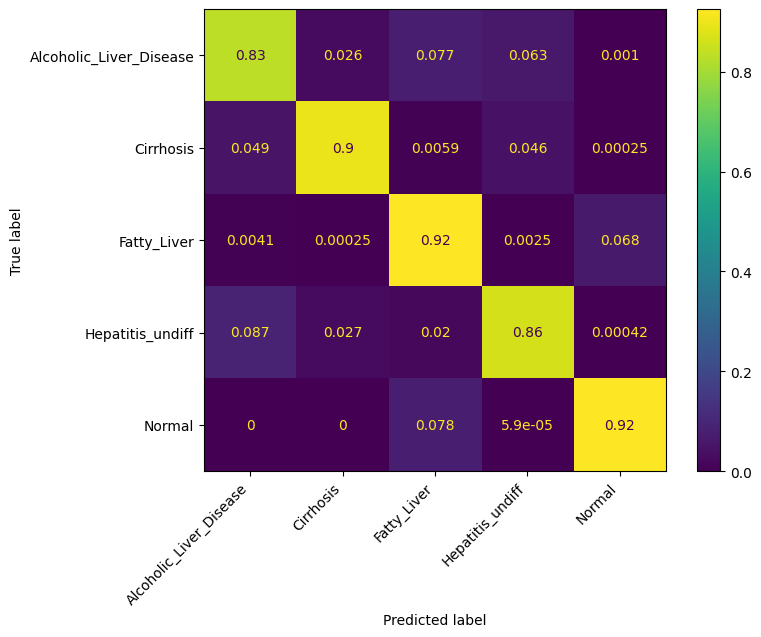

In [8]:
evaluate_pipeline(pipe_xgb, X, y)

In [9]:
pipe_mlp = Pipeline(
    [
        (
            "preprocess",
            ColumnTransformer(
                [
                    ("ohe", OneHotEncoder(drop="first"), columns.categorical),
                    ("scaler", StandardScaler(), columns.numeric),
                ],
                remainder="passthrough",
            ),
        ),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=0.001,
                batch_size="auto",
                learning_rate="adaptive",
                learning_rate_init=0.001,
                max_iter=1000,
                early_stopping=True,
                validation_fraction=0.1,
                random_state=42,
            ),
        ),
    ]
)

Модель MLPClassifier
F1-macro: 0.853 ± 0.008
F1-weighted: 0.863 ± 0.007


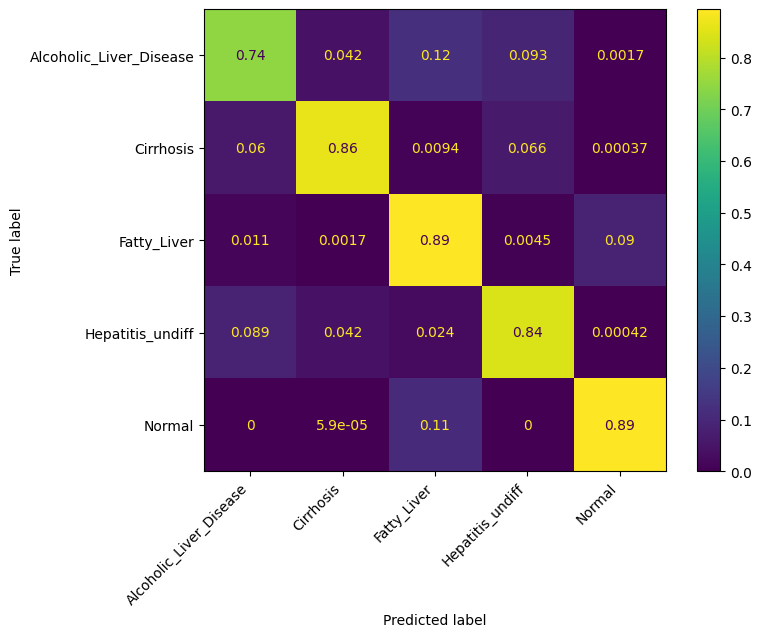

In [10]:
evaluate_pipeline(pipe_mlp, X, y)

In [11]:
estimators_list: list[tuple[str, BaseEstimator]] = [
    ('logreg', pipe_lr),
    ('xgb', pipe_xgb),
    ('mlp', pipe_mlp),
]

In [12]:
stacking_pipe = Pipeline(
    [
        (
            "stacking",
            StackingClassifier(
                estimators=estimators_list,
                final_estimator=LogisticRegression(),
                cv=5,
                n_jobs=-1,
            ),
        )
    ]
)

0 fold: fitting
0 fold: scoring
1 fold: fitting
1 fold: scoring
2 fold: fitting
2 fold: scoring
3 fold: fitting
3 fold: scoring
4 fold: fitting
4 fold: scoring
Модель StackingClassifier
F1-macro: 0.893 ± 0.002
F1-weighted: 0.901 ± 0.002


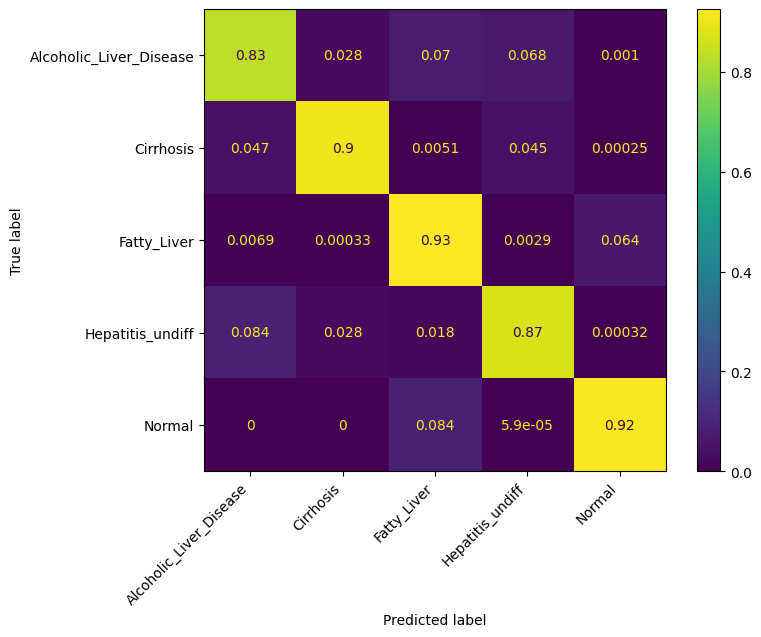

In [13]:
evaluate_pipeline(stacking_pipe, X, y, verbose=True)